In [95]:
import yt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [96]:
os.listdir("./")

['inputs-smoke.inp',
 'plt04211',
 'inputs-case1-nonreacting-CLEM.inp',
 'inputs-case2-reacting.inp',
 'PostProcessing.ipynb',
 '.ipynb_checkpoints',
 'tmp_build_dir',
 'prob.H',
 'inputs-2d.inp',
 'plt10853',
 'plt01655',
 'plt00000',
 'plt_clem_init',
 'chk12511',
 'datlog',
 'chk04211',
 'plt00742',
 'plt02524',
 'Make.package',
 'inputs-case1-nonreacting.inp',
 'plt03373',
 'CMakeLists.txt',
 'plt07546',
 'presRefL2.csv',
 'jinJISCF.tar',
 'chk08374',
 'plt14165',
 'plt08374',
 'PeleC3d.gnu.MPI.ex',
 'plt10028',
 'plt12511',
 'plt05049',
 'Numerical investigation on flow choking induced by local heat release and large scale flow separation in a supersonic combustor - jin2024 (1).pdf',
 'inputs-case1-reacting.inp',
 'prob_parm.H',
 'chk00000',
 'inputs-case2-nonreacting.inp',
 'plt09200',
 'plt05887',
 'plt11682',
 'GNUmakefile',
 'plt13339',
 'Inerte-JISCF-amrL2.ipynb',
 'BLVelRef.csv',
 'plt06718',
 'prob.cpp',
 'jinJISCF']

In [91]:
ds = yt.load("plt14165")


yt : [INFO     ] 2026-08-04 07:00:43,742 Parameters: current_time              = 0.0001700014115162002
yt : [INFO     ] 2026-08-04 07:00:43,743 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-08-04 07:00:43,744 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-08-04 07:00:43,744 Parameters: domain_right_edge         = [12.5  1.5  0.5]


yt : [INFO     ] 2026-08-04 07:00:45,404 xlim = 0.000000 12.500000
yt : [INFO     ] 2026-08-04 07:00:45,405 ylim = 0.000000 1.500000
yt : [INFO     ] 2026-08-04 07:00:45,408 xlim = 0.000000 12.500000
yt : [INFO     ] 2026-08-04 07:00:45,408 ylim = 0.000000 1.500000
yt : [INFO     ] 2026-08-04 07:00:45,411 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800



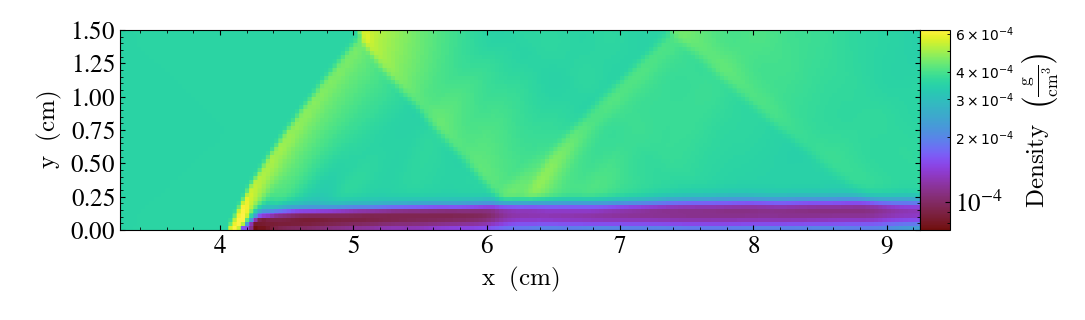

In [92]:
slc = yt.SlicePlot(ds, "z", ("density"), origin="native", center =[6.25, 0.75, 0.25])
slc.set_width(6.0, 1.5)
#slc.pan(())
slc.show()

PRESSURE FIELD AT THE CENTER OF THE CHANNEL

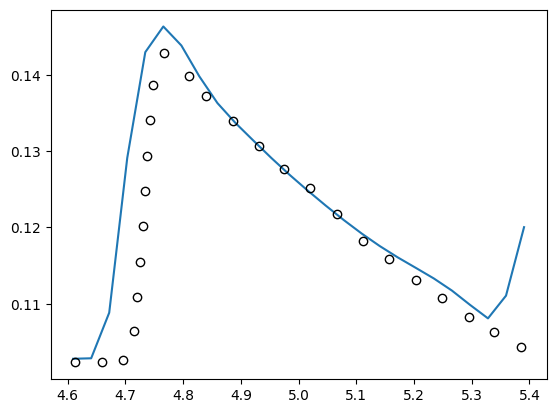

In [107]:
ray = ds.ortho_ray(0, (1.0, 0.25))   # axis 0 = x; coords are (y, z)
p_ref = pd.read_csv("presRefL2.csv")

# sort by x so the line plots cleanly
srt = np.argsort(ray["x"])
x = np.array(ray["x"])
p = np.array(ray["pressure"]/1e7)
srt = np.argsort(x)
x, p = x[srt], p[srt]

m = (x >= 4.6) & (x <= 5.4)
plt.plot(x[m], p[m])
plt.plot(p_ref["x"]/10, p_ref["Pressure"], linestyle ="",
         marker="o", markevery=3,
         markerfacecolor="none",      # hollow markers
         markeredgecolor="black",
         color="black")

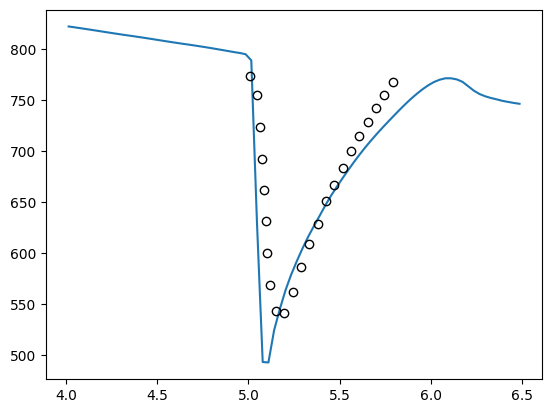

In [94]:
# sort by x so the line plots cleanly
ray = ds.ortho_ray(0, (1.49999, 0.25)) 
srt = np.argsort(ray["x"])
v_ref = pd.read_csv("BLVelRef.csv")


x = np.array(ray["x"])
p = np.array(ray["magvel"]/100)
srt = np.argsort(x)
x, p = x[srt], p[srt]

m = (x >= 4.0) & (x <= 6.5)
plt.plot(x[m], p[m])
plt.plot(v_ref["x"]/10, v_ref["velocity"], linestyle ="",
         marker="o", markevery=3,
         markerfacecolor="none",      # hollow markers
         markeredgecolor="black",
         color="black")

yt : [INFO     ] 2026-08-04 07:04:52,901 Parameters: current_time              = 8.000019628851029e-05
yt : [INFO     ] 2026-08-04 07:04:52,901 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-08-04 07:04:52,902 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-08-04 07:04:52,902 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2026-08-04 07:04:53,371 Parameters: current_time              = 0.00011000186336491491
yt : [INFO     ] 2026-08-04 07:04:53,371 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-08-04 07:04:53,372 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-08-04 07:04:53,373 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2026-08-04 07:04:53,721 Parameters: current_time              = 0.00014000568697791006
yt : [INFO     ] 2026-08-04 07:04:53,722 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-08

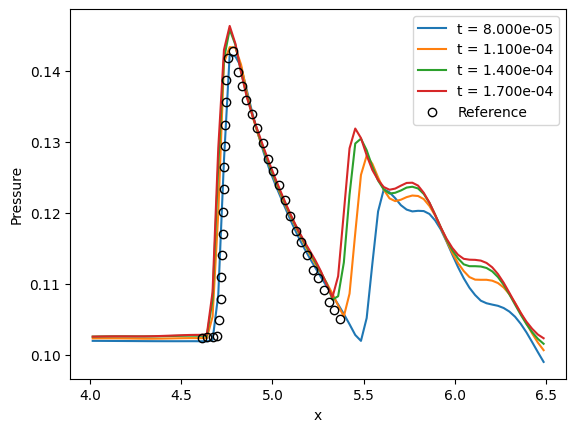

In [101]:


files = os.listdir(".")
plts = [f for f in files if re.fullmatch(r"plt\d+", f)]
plts.sort(key=lambda f: int(f[3:]))
plts = [f for f in plts if int(f[3:]) >= 6718][::3]

# reference (plot once)
p_ref = pd.read_csv("presRefL2.csv")

plt.figure()
for f in plts:
    ds  = yt.load(f)
    ray = ds.ortho_ray(0, (1.0, 0.25))   # x-parallel ray at y=1.0, z=0.25

    x = np.array(ray["x"])
    p = np.array(ray["pressure"] / 1e7)
    srt = np.argsort(x)
    x, p = x[srt], p[srt]

    m = (x >= 4.0) & (x <= 6.5)
    plt.plot(x[m], p[m], label=f"t = {float(ds.current_time):.3e}")

# reference, hollow black markers
plt.plot(p_ref["x"]/10, p_ref["Pressure"],
         linestyle="", marker="o", markevery=2,
         markerfacecolor="none", markeredgecolor="black",
         label="Reference")

plt.xlabel("x")
plt.ylabel("Pressure")
plt.legend()
plt.show()

yt : [INFO     ] 2026-08-04 07:05:42,191 Parameters: current_time              = 8.000019628851029e-05
yt : [INFO     ] 2026-08-04 07:05:42,192 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-08-04 07:05:42,192 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-08-04 07:05:42,193 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2026-08-04 07:05:42,611 Parameters: current_time              = 0.00011000186336491491
yt : [INFO     ] 2026-08-04 07:05:42,612 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-08-04 07:05:42,613 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-08-04 07:05:42,613 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2026-08-04 07:05:42,964 Parameters: current_time              = 0.00014000568697791006
yt : [INFO     ] 2026-08-04 07:05:42,965 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-08

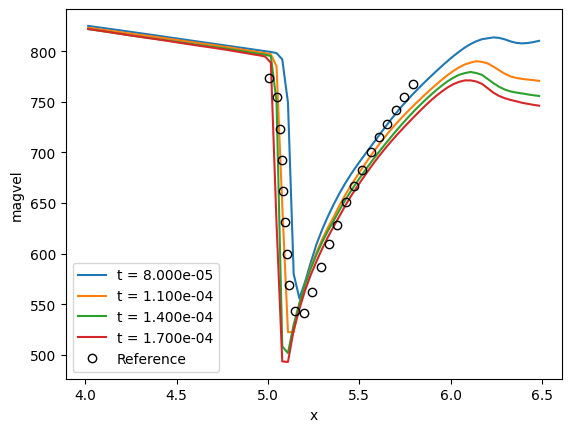

In [102]:
files = os.listdir(".")
plts = [f for f in files if re.fullmatch(r"plt\d+", f)]
plts.sort(key=lambda f: int(f[3:]))
plts = [f for f in plts if int(f[3:]) >= 6718][::3]

# reference (plot once)
v_ref = pd.read_csv("BLVelRef.csv")

plt.figure()
for f in plts:
    ds  = yt.load(f)
    ray = ds.ortho_ray(0, (1.49999, 0.25))   # x-parallel ray at y=1.49999, z=0.25

    x = np.array(ray["x"])
    p = np.array(ray["magvel"] / 100)
    srt = np.argsort(x)
    x, p = x[srt], p[srt]

    m = (x >= 4.0) & (x <= 6.5)
    plt.plot(x[m], p[m], label=f"t = {float(ds.current_time):.3e}")

# reference, hollow black markers
plt.plot(v_ref["x"]/10, v_ref["velocity"],
         linestyle="", marker="o", markevery=3,
         markerfacecolor="none", markeredgecolor="black",
         label="Reference")

plt.xlabel("x")
plt.ylabel("magvel")
plt.legend()
plt.show()